<a href="https://colab.research.google.com/github/komazawa-deep-learning/komazawa-deep-learning.github.io/blob/master/2024notebooks/2024_1220Karapetian_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Karapetian+ (2023), Empirically Identifying and Computationally Modeling the Brain–Behavior Relationship for Human Scene Categorization, Journal of Cognitive Neuroscience 35:11, pp. 1879–1897, doi:10.1162/jocn_a_02043

データは，https://osf.io/4fdky/ より入手して，駒澤 Gdrive で共有

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'device:{device}')

import os
try:
    import ipynb_path
except ImportError:
    !pip install ipynb-path
    import ipynb_path
__file__ = os.path.basename(ipynb_path.get())
print(f'__file__:{__file__}')

import numpy as np
import sys
import zipfile
import glob

import IPython
isColab = 'google.colab' in str(IPython.get_ipython())

if isColab:
    from google.colab import drive
    drive.mount('/content/drive')

    img_basedir = '/content/drive/Shareddrives/2023Karapetian_data/Stimuli'
    fnames = list(sorted(glob.glob(os.path.join(img_basedir,'*.jpg'))))
else:
    HOME = os.environ['HOME']
    img_basedir = os.path.join(HOME, 'study/2024Agnessa14_Perceptual-decision-making.git/Stimuli')
    fnames = list(sorted(glob.glob(os.path.join(img_basedir,'*.jpg'))))

import matplotlib.pyplot as plt
import PIL

try:
    import japanize_matplotlib
except ImportError:
    !pip install japanize_matplotlib
    import japanize_matplotlib

device:cpu
__file__:fileId=1bHyE9vqQBuDXUBlUsnZfO9MFIcEMsK-M
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Karapetian+(2023) で用いられた刺激画像の表示

In [ ]:
# 刺激画像の表示
nrows, ncols = 6, 10
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12,9))
#fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14,10))

i=0
for row in range(nrows):
    for col in range(ncols):
        img = PIL.Image.open(img_basedir+'/'+str(i+1)+'.jpg').convert('RGB')
        ax[row][col].imshow(img)
        ax[row][col].axis('off')
        ax[row][col].set_title(f'{i+1}')
        i += 1

# 1-10: アパート
#11-20: ベッド
#21-30: 高速道路
#31-40: 海岸
#41-50: 峡谷
#51-60: 森林
# 1-30 は，人工物情景であり，31-60 は，自然情景

# [Karapetian+2023 Github readme.txt](https://github.com/Agnessa14/Perceptual-decision-making/blob/master/README.md)

## readme.txt

この ReadMe は Empirically identifying and computationally modelling the brain-behaviour relationship for human scene categorization プロジェクトの OSF リポジトリの ReadMe である。
原稿で使用されたヒト (N=30) とモデルのデータが含まれている。
<!-- This is a ReadMe for the OSF repository to the project "Empirically identifying and computationally modelling the brain-behaviour relationship for human scene categorization" containing human (N=30) and model data used in the manuscript. -->

### 一般情報

注意散漫課題のデータは、後に用語が変更されたため fixation という名前で保存されている。
被験者の名前は，元の記録ファイルとの整合性を保つため，記録された名前 (5:26, 28:35) に従っている。
アップロードされたのは前処理済みのデータのみである。
生データにアクセスするには，遠慮なく agnessakarapetian@gmail.com まで。
<!--The data for the distraction task is saved under the name "fixation" due to a later change in terminology.
The subjects are named according to the names under which they were recorded (5:26, 28:35) to remain consistent with the original recording files.
Only preprocessed data were uploaded; to get access to raw data, don't hesitate to contact agnessakarapetian@gmail.com.   -->

### 前処理済 EEG データ

EEG データは，Fieldtrip の関数を用いて Matlab 2021a で前処理した。
そのため，前処理されたデータは Matlab の構造体（`timelock_categorization.mat` または `timelock_fixation.mat`）ファイルとして保存され，`timelock.trial` には各試行，電極 (計 63)，時点 (合計 200) の情報が含まれている。
刺激 ID は `timelock.trialinfo` の下にある。
前処理の詳細は原稿を参照。
<!--EEG data were preprocessed in Matlab 2021a using functions from Fieldtrip. The preprocessed data are therefore saved as a Matlab structure (timelock_categorization.mat or timelock_fixation.mat) file and timelock.trial contains information for each trial, electrode (total 63) and time point (total 200).
The stimulus IDs are under timelock.trialinfo. For preprocessing details, please refer to the manuscript.   -->

### 前処理済行動データ

被験者レベルの反応時間と課題精度は，EEG データの前処理後の全試行について利用可能である。
各被験者の正しい試行の反応時間は，刺激セットと同じ順序で `Behaviour/All_subjects` にある。
完全な行動データファイルについては，問い合わせてほしい。
<!--Subject-level reaction times and task accuracy are available for all trials that remained after preprocessing the EEG data.
The reaction times for the correct trials for each subject are available in Behaviour/All_subjects, in the same order as in the stimulus set.  
For complete behavioural data files, please get in touch.  -->

### モデル（RCNN）の行動データと重み

RCNN フォルダには，論文で使用した微調整済 RCNN の重み係数行列がある。
これは，BLnet (Spoerer+2020) であり，econet データセット (Mehrer2017) を用いて訓練し，Places-365 データセット (Zhou+2018) をもちいて微調整した。
シーン分類課題に対するモデルの反応時間を利用可能にし、刺激セットと同じ順序に従う。
<!--The RCNN folder contains weights for the fine-tuned RCNN used in the paper, BLnet (Spoerer et al., 2020), initially trained on ecoset (Mehrer et al., 2017)
but fine-tuned on a subset of Places-365 (Zhou et al., 2018).
The reaction times of the model to the scene categorization task are made available and follow the same order as in the stimulus set.  -->

### 刺激セット

刺激セットは 60 の情景画像で構成され，前半は人工物の情景，後半は自然物情景の画像である。
これらは Places-365 (Zhou+2018) の検証セットから取られ，中央で切り取られ，480x480 にリサイズされた。
オリジナルの画像については、`http://places2.csail.mit.edu/download.html`
<!--The stimulus set consists of 60 scene images: the first half depicts man-made scenes and the second half natural. These were taken from the validation set of Places-365 (Zhou et al., 2018), center-cropped and resized to 480x480.
For original images, please refer to http://places2.csail.mit.edu/download.html.  -->




In [ ]:
import scipy
import scipy.io  # Python から MATLAB で用いられるデータ .mat 形式のファイルを読み込むためには `scipy.io` が必要となる。
import seaborn

cmap = 'rainbow'
cmap = 'jet'
if isColab:
    basedir = "/content/drive/Shareddrives/2023Karapetian_data/Behaviour/All_subjects/RTs"
else:
    basedir = os.path.join(HOME, 'study/2024Agnessa14_Perceptual-decision-making.git/Behaviour/All_subjects/RTs')


# EEG データの読み込み

## その前に電極の位置と名前を確認

In [ ]:
if not os.path.exists('ASP-64.png'):
    !wget https://komazawa-deep-learning.github.io/2024assets/ASP-64.png -O ASP-64.png
eeg_channels_img = PIL.Image.open('ASP-64.png')
plt.figure(figsize=(8,8))
plt.axis(False)
plt.imshow(eeg_channels_img)

In [ ]:
import pickle
import os

# 事前に加工したデータを読み込む
pkl_fname = '2024_1205Stim_Chn_Karapetian2023.pkl'
if isColab:
    base_dir = '/content/drive/Shareddrives/2023Karapetian_data/'
    pkl_fname = os.path.join(base_dir, pkl_fname)

with open(pkl_fname, 'rb') as f:
    _Stim_Chn = pickle.load(f)

len(cond_scenes):6


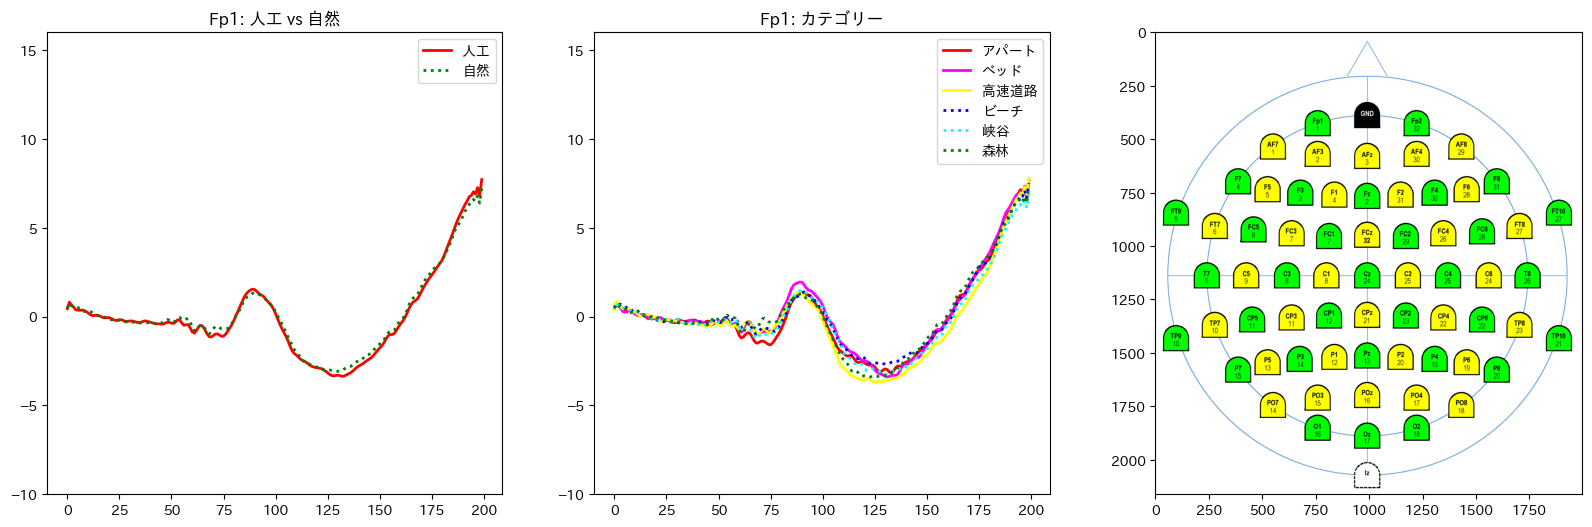

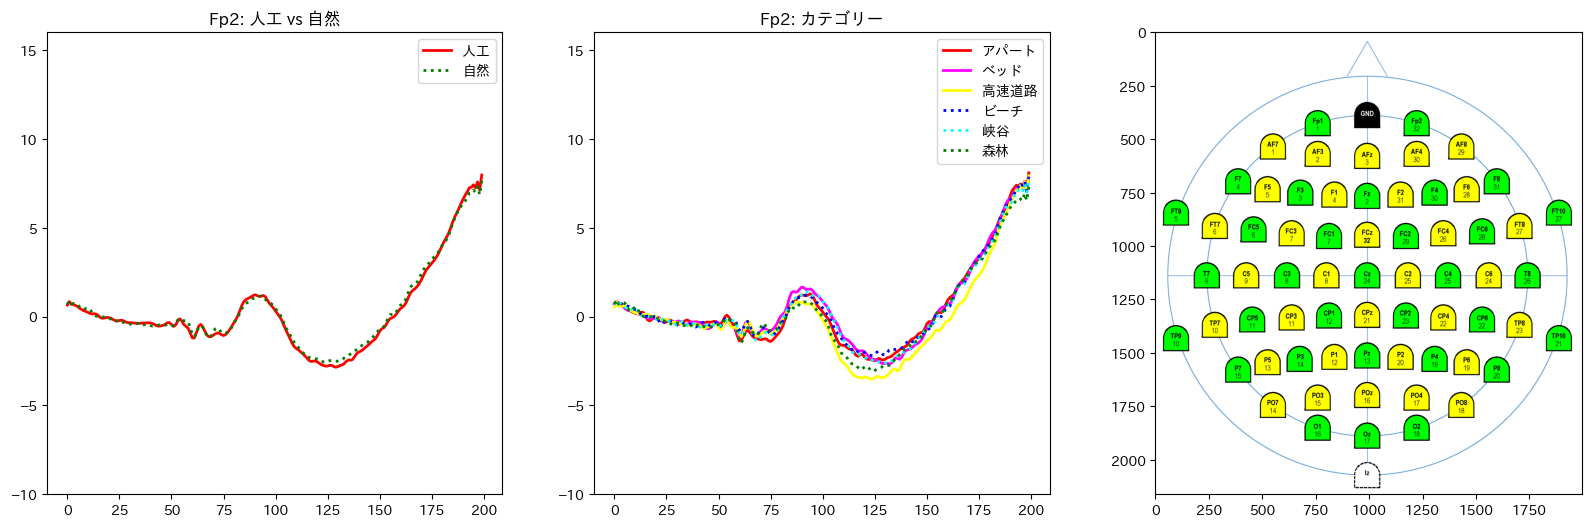

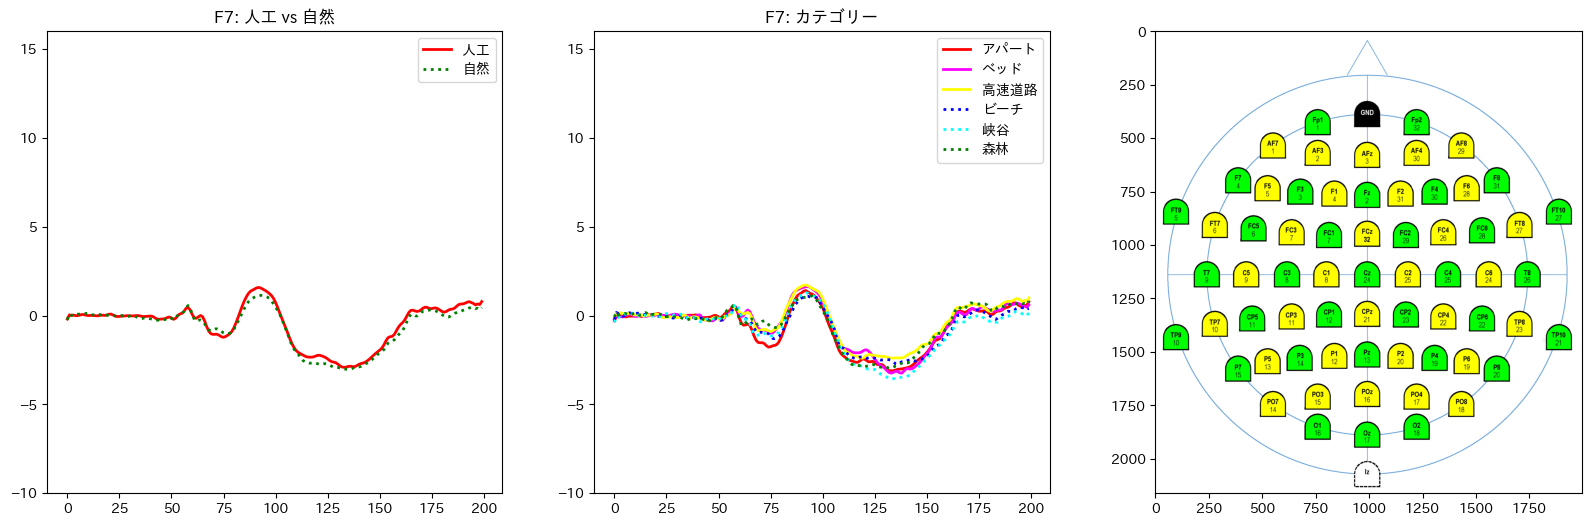

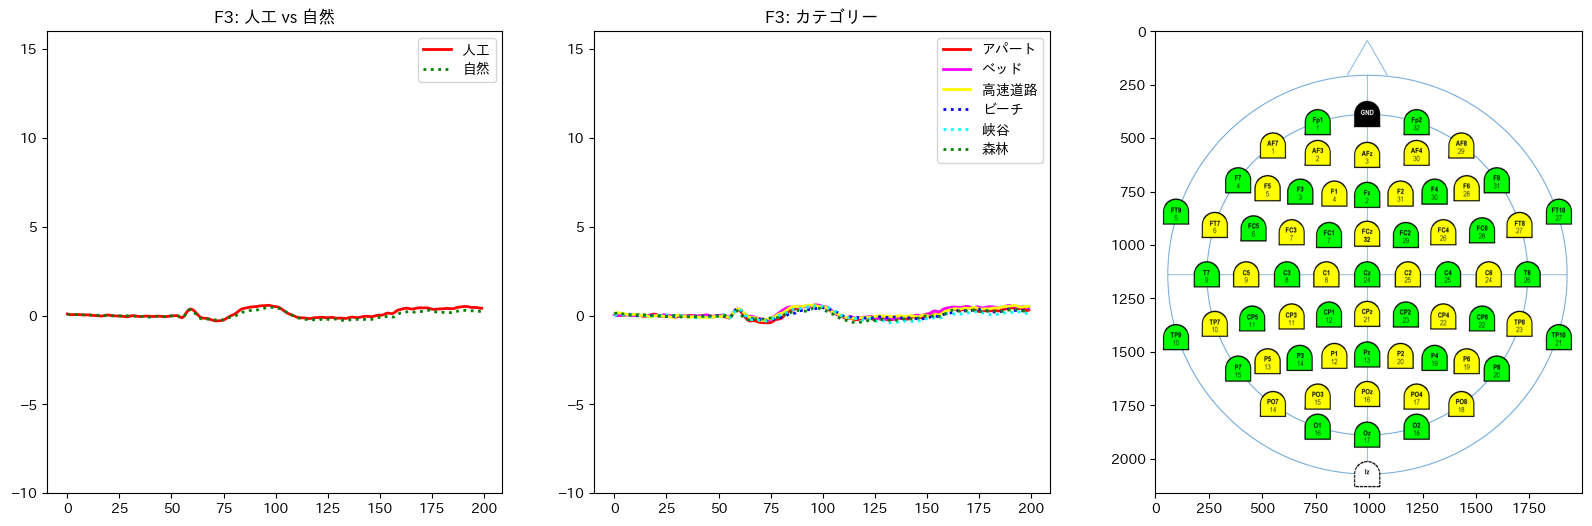

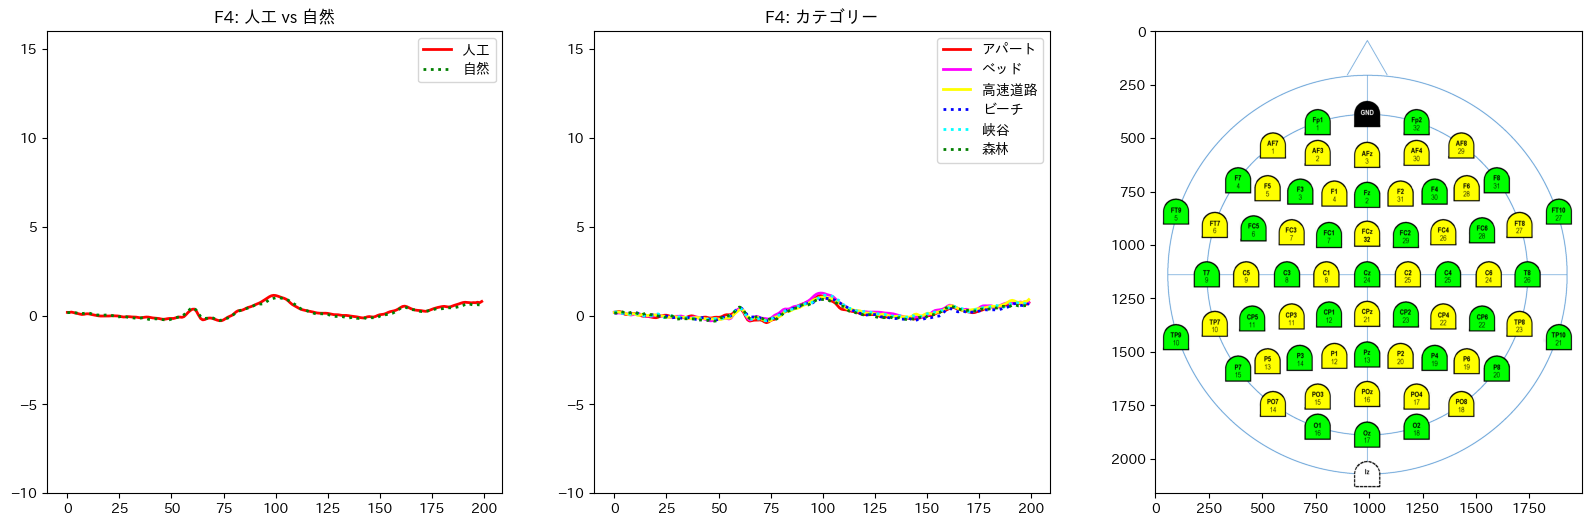

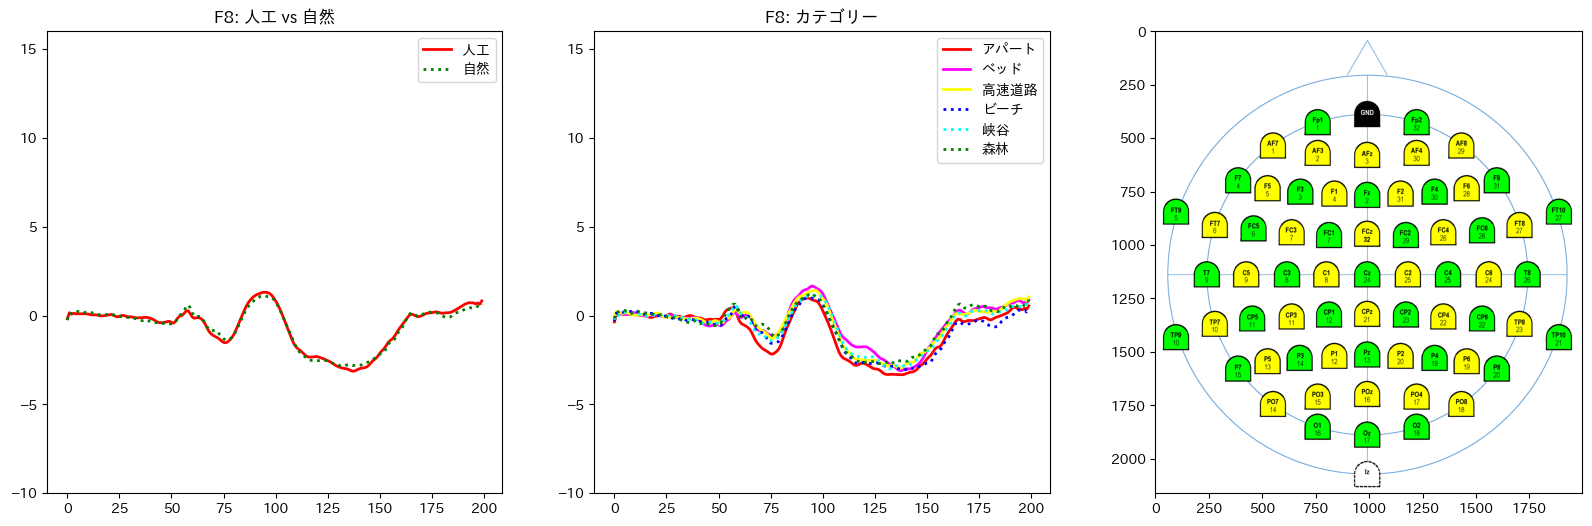

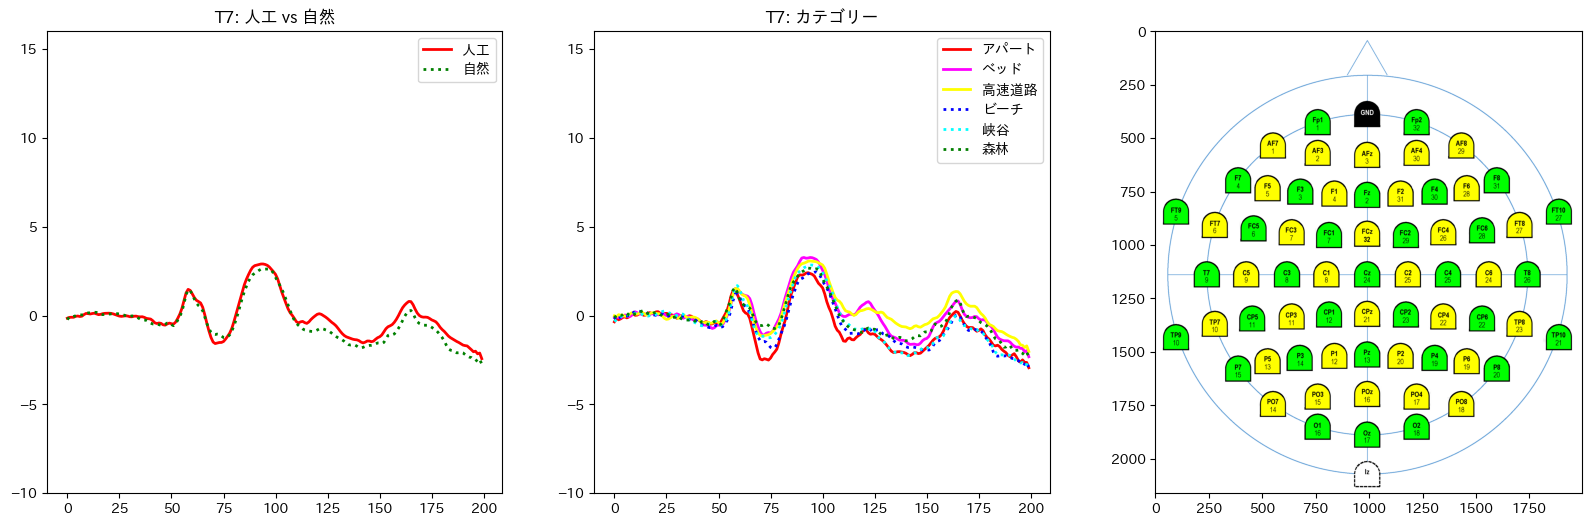

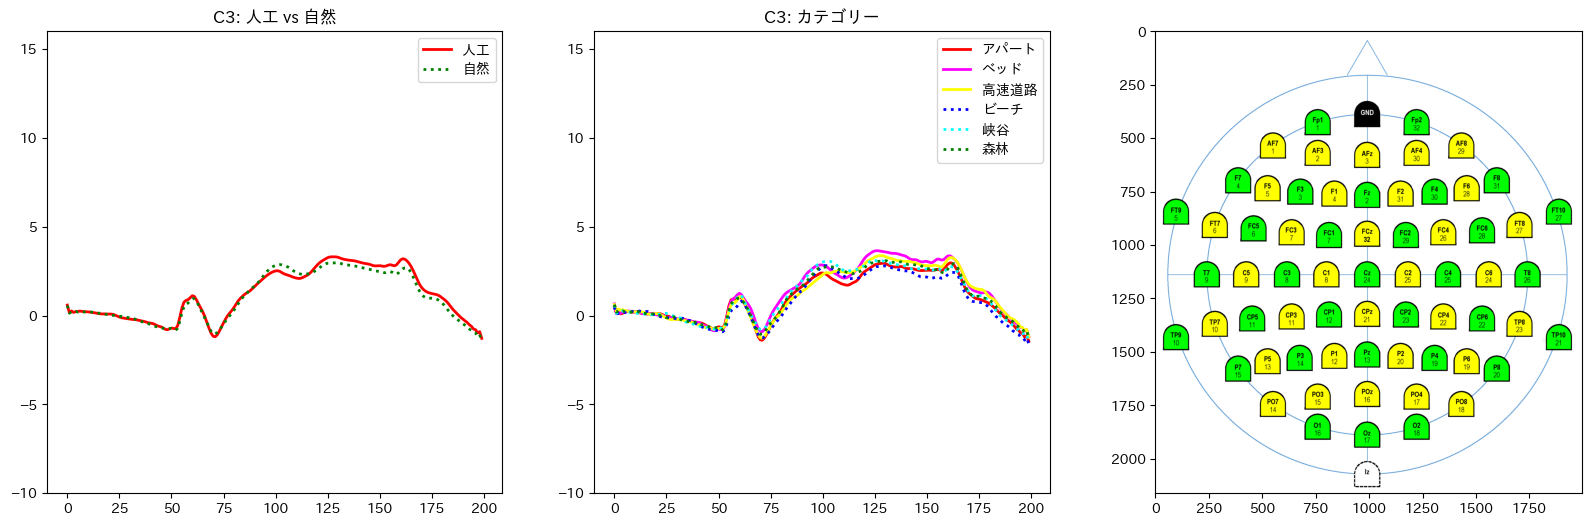

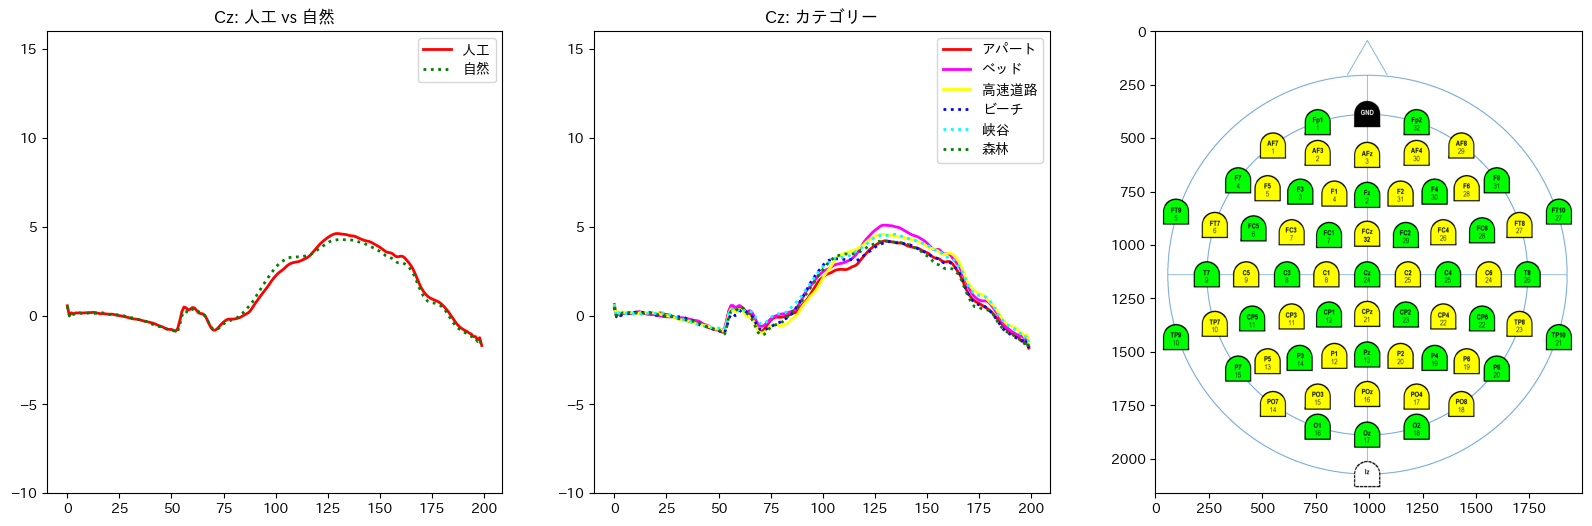

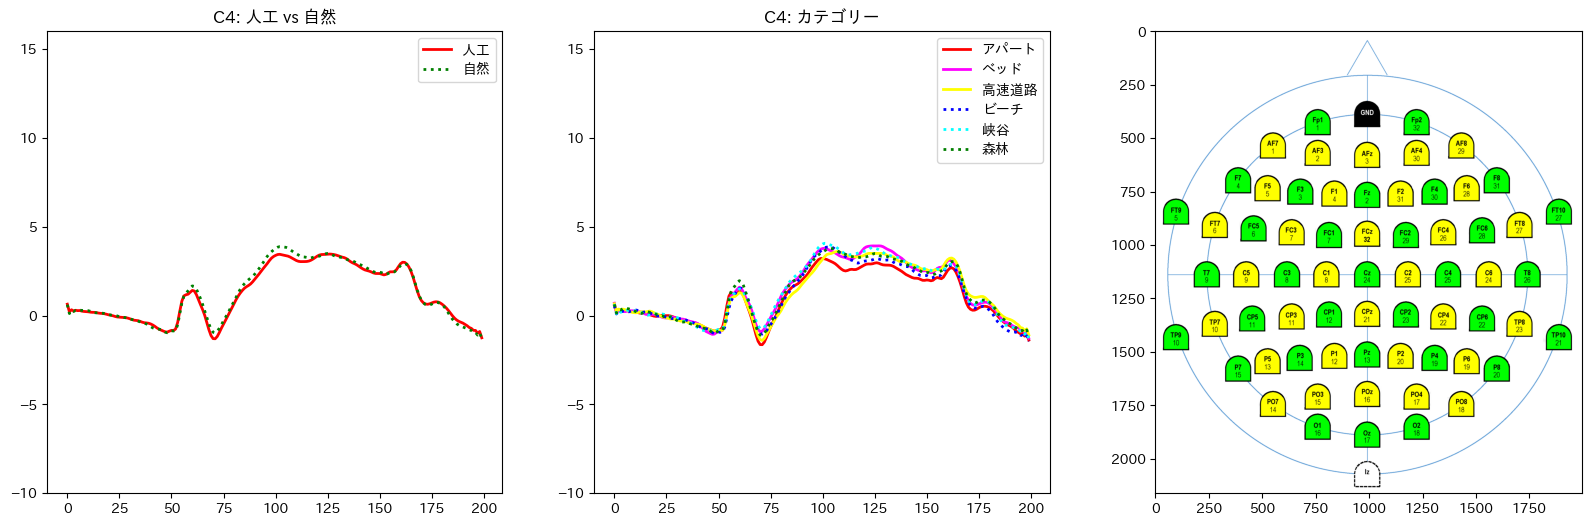

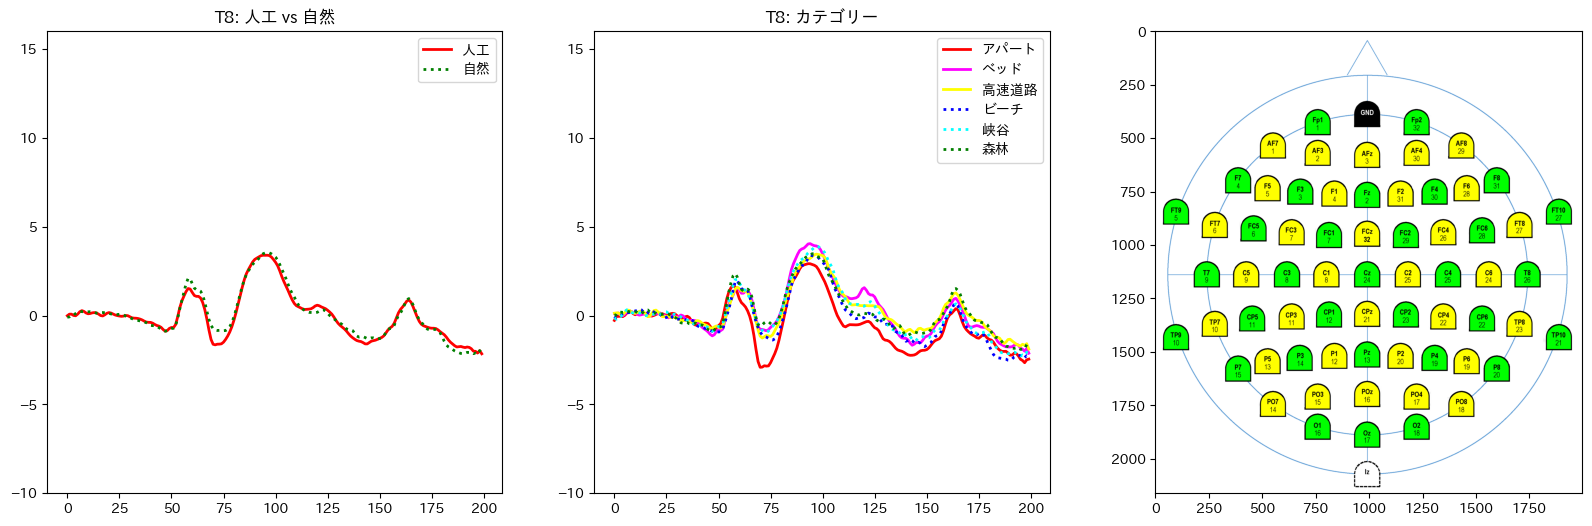

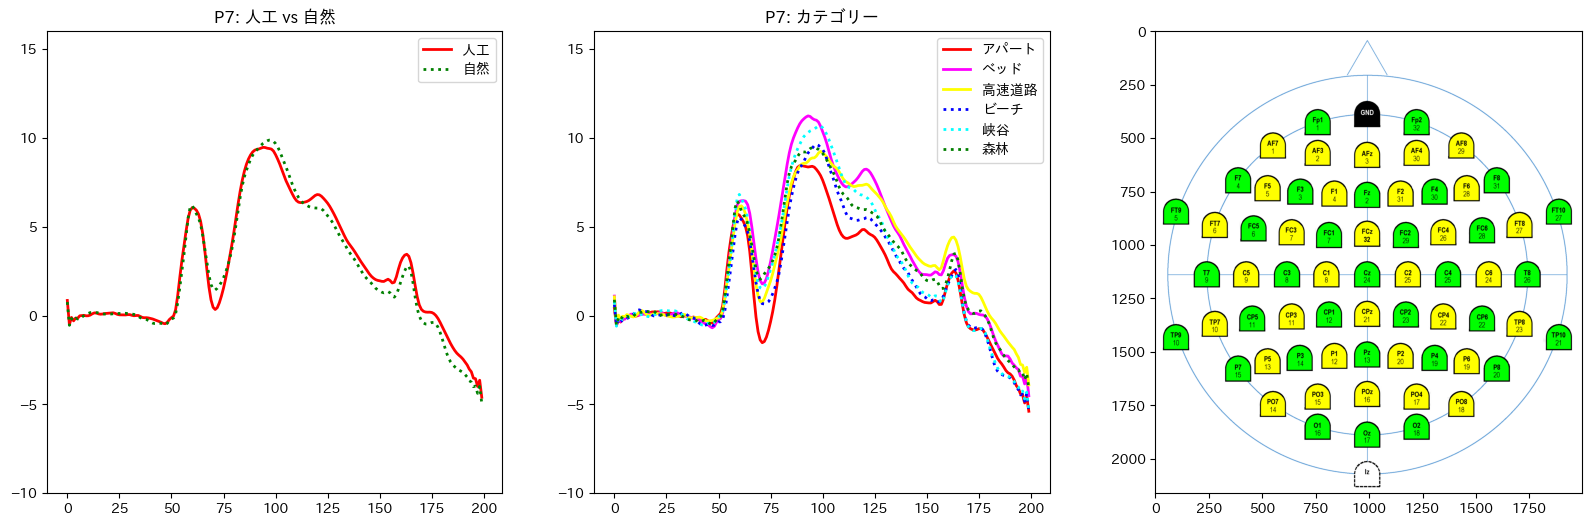

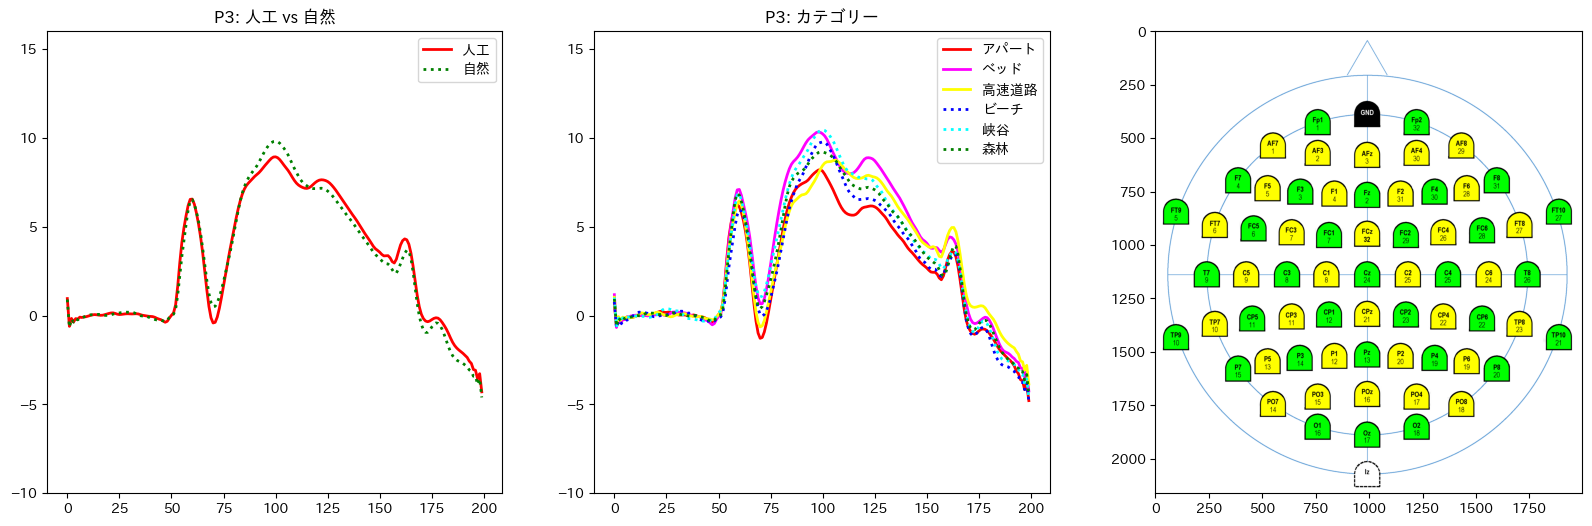

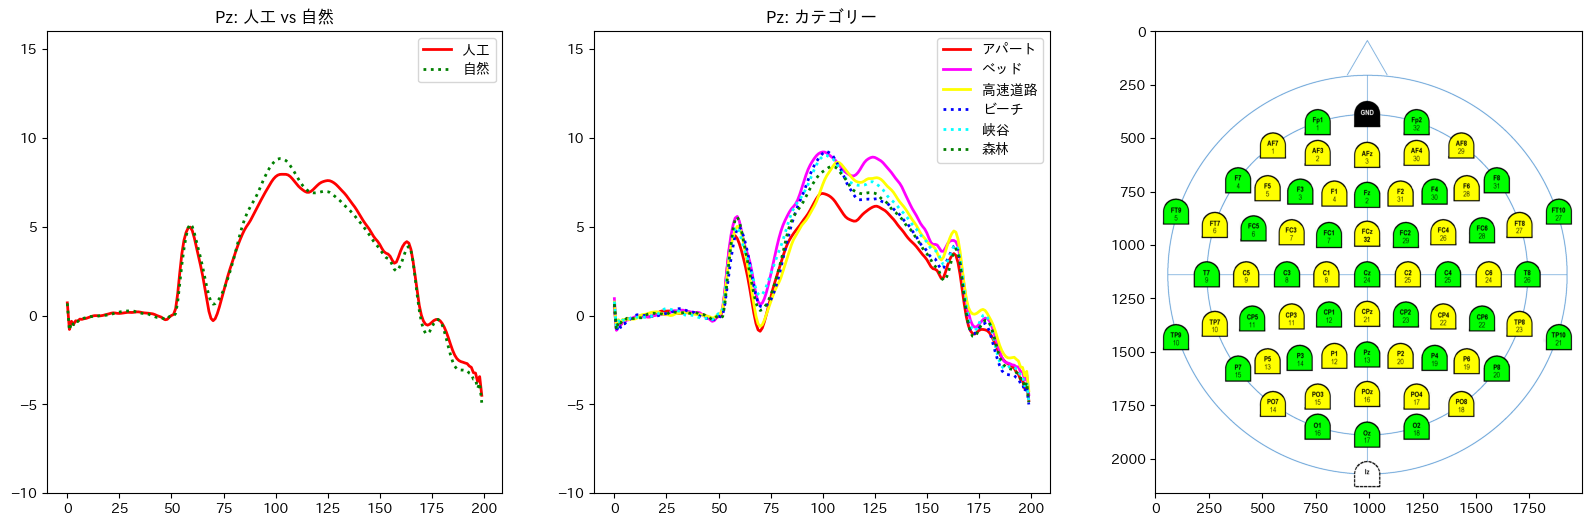

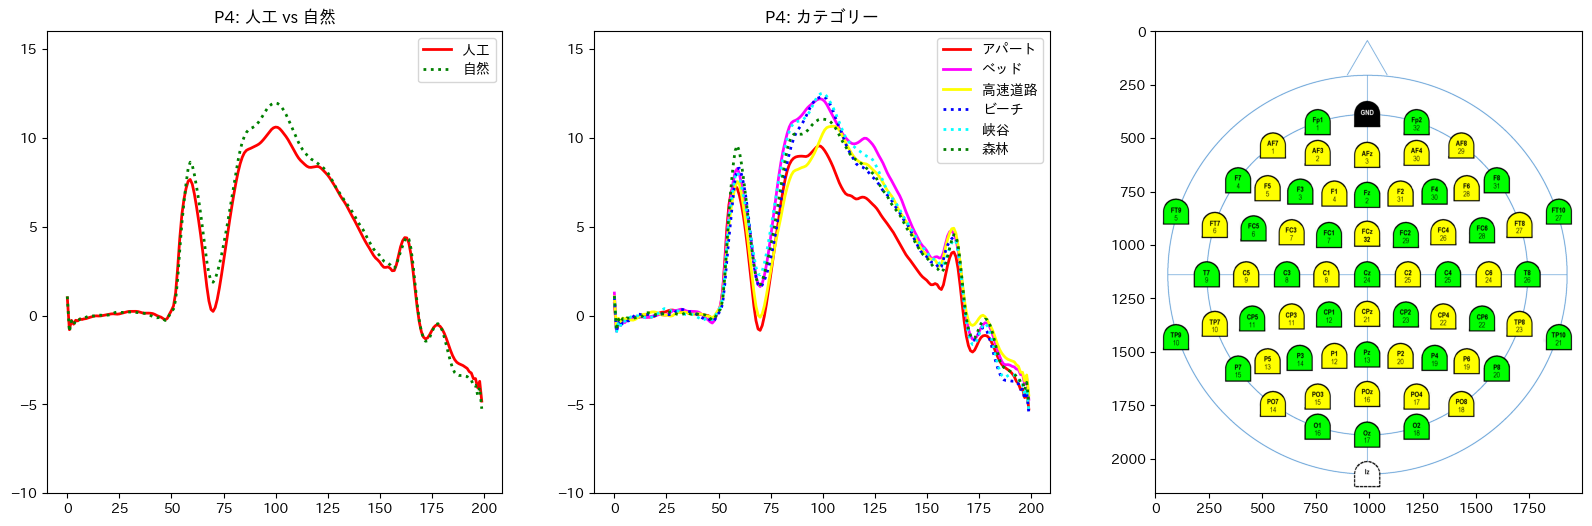

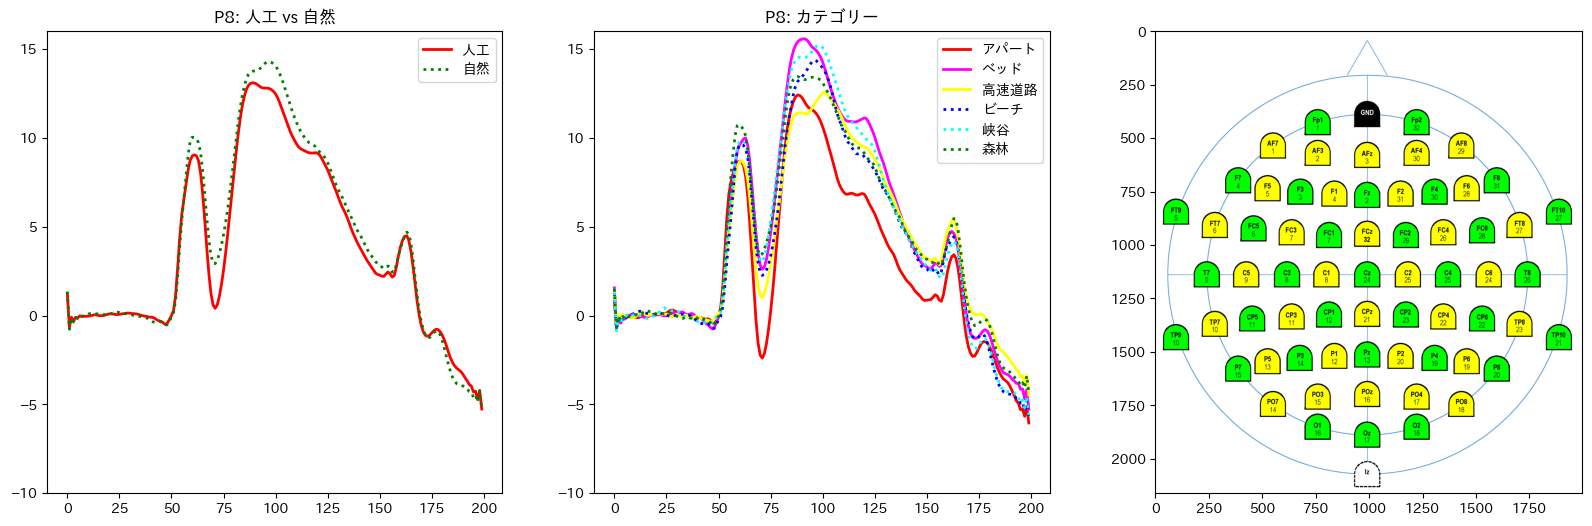

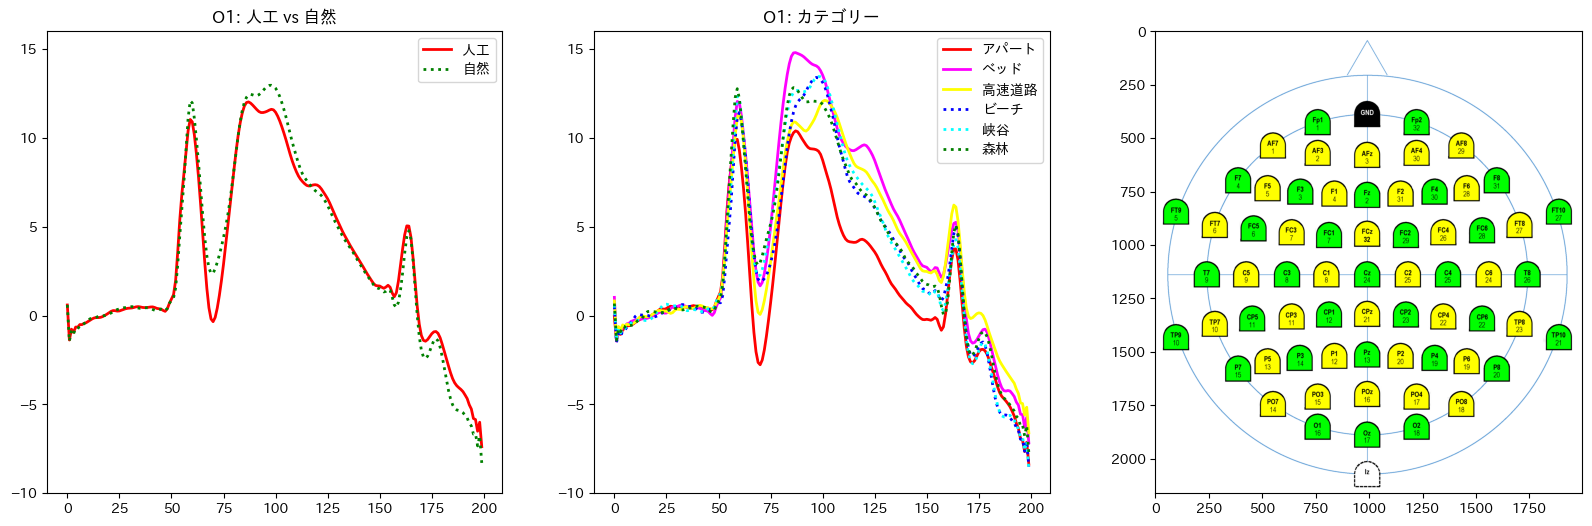

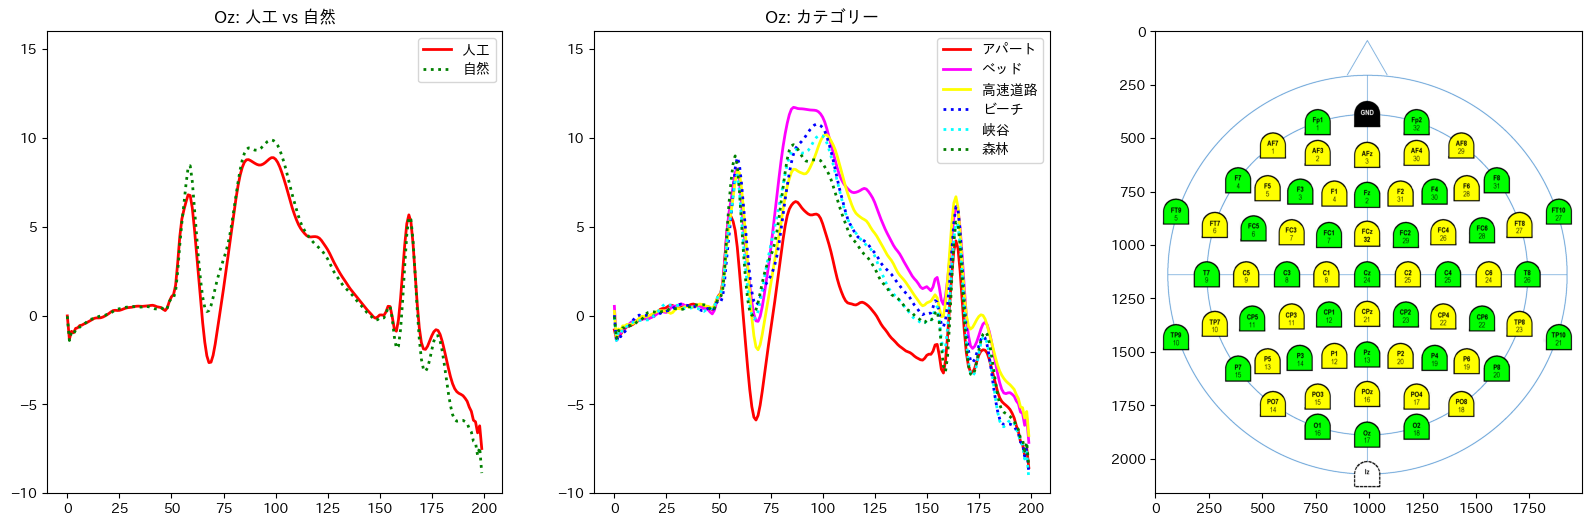

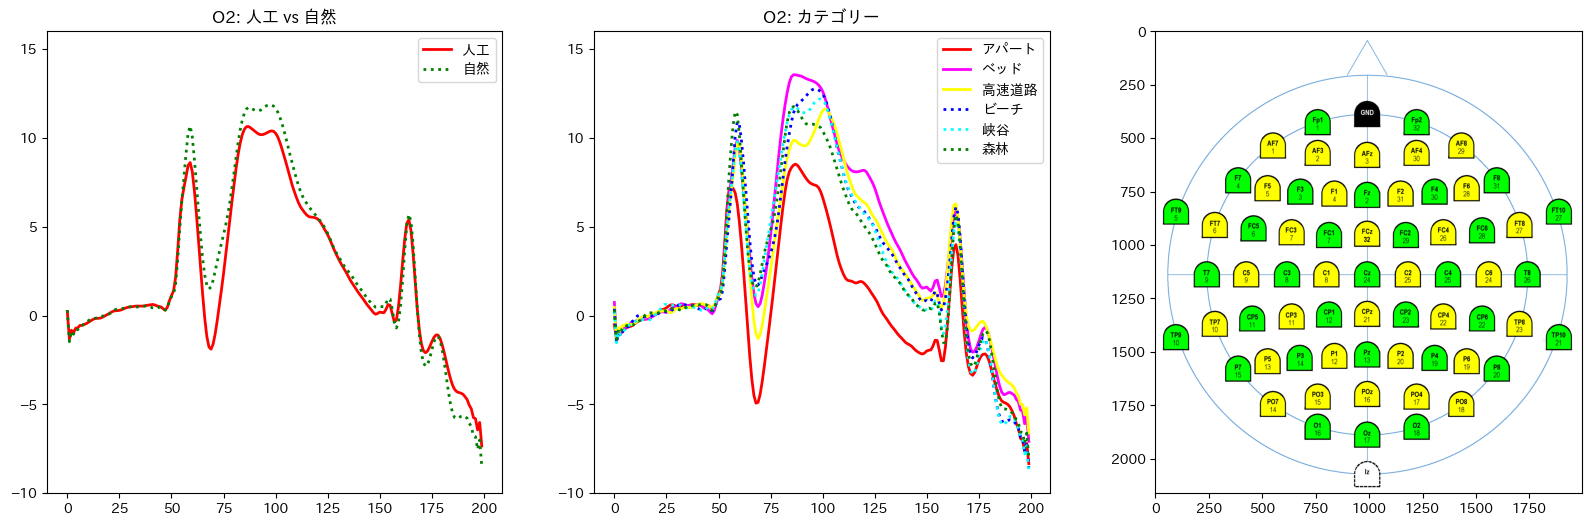

In [ ]:
stim_nums = [i+1 for i in range(60)]
# 1-10: アパート
#11-20: ベッド
#21-30: 高速道路
#31-40: 海岸
#41-50: 峡谷
#51-60: 森林

#EEG_chns = _Stim_Chn[1].keys()
EEG_chns = [
    'Fp1', 'Fp2',
    'F7', 'F3', 'F4', 'F8',
    #'F7', 'F3', 'Fz', 'F4', 'F8',
    'T7', 'C3', 'Cz', 'C4', 'T8',
    'P7', 'P3', 'Pz', 'P4', 'P8',
    'O1', 'Oz', 'O2'
]

cond_aprt = range(1,11,1)
cond_beds = range(11,21,1)
cond_higw = range(21,31,1)
cond_beac = range(31,41,1)
cond_vall = range(41,51,1)
cond_fore = range(51,61,1)

cond_scenes = [(cond_aprt, 'アパート', 'red', '-'),
               (cond_beds, 'ベッド', 'magenta', '-'),
               (cond_higw, '高速道路', 'yellow', '-'),
               (cond_beac, 'ビーチ', 'blue', ':'),
               (cond_vall, '峡谷', 'cyan', ':'),
               (cond_fore, '森林', 'green', ':')]

print(f'len(cond_scenes):{len(cond_scenes)}')

cond_art = range(1,31,1)
cond_nat = range(31,61,1)
cond_cats = [(cond_art, '人工', 'red', '-'), (cond_nat, '自然', 'green', ':')]


ylim = (-10,16)
def draw_a_channel(chn='Cz',
                   figsize=(20,6)):
    fig, axes = plt.subplots(figsize=figsize, ncols=3)

    # fig.canvas.draw()
    # # 座標値などを決めるために呼び出しておく。これを呼び出さずに、get_xticklabels()を読んでも文字列が取れない
    # # plot.show()だとプロットが Fix してしまうのでダメ

    # x_tick_labels = {0:"-200", 25:"", 50:" 000", 75:"", 100:"+200", 125:"", 150:"+400", 175:"", 200:"+800"} #置き換える座標と文字列を辞書で定義しておく

    # #辞書に登録した座標の位置を置き換えていく
    # #それ以外の位置は空白とする
    # x_ticks_ = []
    # # for item in axes[0].get_xticklabels():
    # for k in range(201):
    #     if k in x_tick_labels:
    #         x_ticks_.append(x_tick_labels[k])
    #     else:
    #         x_ticks_.append("")
    #         #x_ticks_.append(None)
    # #print(f'len(x_ticks_):{len(x_ticks_)}')
    # plt.setp(axes, xticks=range(9), xticklabels=x_tick_labels)

    for _cond, tag, color, linestyle in cond_cats:
        X = []
        for stim_no in _cond:
            X.append(_Stim_Chn[stim_no][chn])
        axes[0].plot(np.mean(np.array(X),axis=0), label=tag, color=color, linewidth=2, linestyle=linestyle)
    axes[0].set_title(f'{chn}: 人工 vs 自然')
    axes[0].legend()
    axes[0].set_ylim(ylim)

    for _cond, tag, color, linestyle in cond_scenes:
        X = []
        for stim_no in _cond:
            X.append(_Stim_Chn[stim_no][chn])
        axes[1].plot(np.mean(np.array(X),axis=0), label=tag, color=color, linewidth=2, linestyle=linestyle)
    axes[1].set_title(f'{chn}: カテゴリー')
    axes[1].legend()
    axes[1].set_ylim(ylim)

    axes[2].imshow(eeg_channels_img)
    plt.show()


for chn in EEG_chns:
    draw_a_channel(chn=chn)

In [ ]:
print(_Stim_Chn[1].keys())
# ['Fp1', 'Fp2',
# 'AF7', 'AF3', 'AFz', 'AF4', 'AF8',
# 'F7', 'F5', 'F3', 'F1', 'F2', 'F4', 'F6', 'F8',
# 'FT9', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'FT10',
# 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8',
# 'TP9', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'TP10',
# 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8',
# 'PO7', 'PO3', 'POz', 'PO4', 'PO8',
# 'O1', 'Oz', 'O2'])

dict_keys(['Fp1', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'F2', 'F4', 'F6', 'F8', 'FT9', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'FT10', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP9', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'TP10', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2'])
